In [1]:
import pandas as pd
import numpy as np
import psycopg2
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import psycopg2
import pandas as pd

conn = psycopg2.connect(
    host="localhost",
    database="stock_market_db",
    user="postgres",
    password="rishiraj"
)

query = "SELECT * FROM stock_data"

df = pd.read_sql(query, conn)

df.head()

C:\Users\rajpu\AppData\Local\Temp\ipykernel_5476\1101190555.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


,id,symbol,asset_type,open,high,low,close,volume,ingestion_time,market_timestamp,source
0,1,NIFTY50,INDEX,23101.35,23105.10,23093.55,23103.70,0,2026-06-08 23:11:06.205877,2026-06-08 15:29:00,Yahoo Finance
1,2,BANKNIFTY,INDEX,53981.40,54007.35,53949.90,54007.35,0,2026-06-08 23:11:06.852352,2026-06-08 15:29:00,Yahoo Finance
2,3,SENSEX,INDEX,73522.61,73525.81,73522.61,73524.22,0,2026-06-08 23:11:07.070844,2026-06-08 15:29:00,Yahoo Finance
3,4,RELIANCE,STOCK,1262.80,1262.90,1261.80,1262.80,58641,2026-06-08 23:11:07.326910,2026-06-08 15:29:00,Yahoo Finance
4,5,TCS,STOCK,2153.60,2154.00,2150.10,2153.00,35657,2026-06-08 23:11:07.526029,2026-06-08 15:29:00,Yahoo Finance


In [3]:
df.describe()

,id,open,high,low,close,volume,ingestion_time,market_timestamp
count,34124.000000,34124.000000,34124.000000,34124.000000,34124.000000,3.412400e+04,34124,34124
mean,17094.487926,12955.635844,12959.120683,12951.955048,12955.521811,3.518354e+04,2026-06-08 23:13:39.402111488,2026-06-03 12:22:05.350486528
min,1.000000,275.250000,275.450012,275.100006,275.149994,0.000000e+00,2026-06-08 23:11:06.205877,2026-05-29 09:15:00
25%,8560.750000,1199.574982,1200.000000,1199.000000,1199.574982,9.640000e+02,2026-06-08 23:13:36.930511872,2026-06-01 13:56:00
50%,17094.500000,1812.900024,1813.500000,1812.149963,1812.800049,1.122000e+04,2026-06-08 23:13:39.632783104,2026-06-03 12:22:00
75%,25628.250000,4022.275024,4024.849976,4020.924927,4022.025024,3.340025e+04,2026-06-08 23:13:42.295222016,2026-06-05 10:48:00
max,34162.000000,76141.187500,76213.601562,76108.656250,76143.367188,1.344306e+07,2026-06-08 23:13:45.057902,2026-06-08 15:29:00
std,9854.643530,22987.109295,22992.571727,22981.390400,22986.958332,1.433841e+05,NaN,NaN


In [4]:
df["return_pct"] = (
    (df["close"] - df["open"])
    / df["open"]
) * 100

df.sort_values(
    by="return_pct",
    ascending=False
).head(10)

,id,symbol,asset_type,open,high,low,close,volume,ingestion_time,market_timestamp,source,return_pct
31789,31828,ASIANPAINT,STOCK,2678.000000,2743.899902,2677.600098,2729.100098,125442,2026-06-08 23:13:45.057902,2026-05-29 14:04:00,Yahoo Finance,1.908144
31791,31830,ASIANPAINT,STOCK,2640.899902,2685.000000,2633.000000,2682.500000,176388,2026-06-08 23:13:45.057902,2026-05-29 14:06:00,Yahoo Finance,1.575224
13507,13539,INFY,STOCK,1175.800049,1193.800049,1175.800049,1192.500000,0,2026-06-08 23:13:38.639203,2026-06-01 09:15:00,Yahoo Finance,1.420305
13132,13164,INFY,STOCK,1183.599976,1195.400024,1180.500000,1195.400024,0,2026-06-08 23:13:38.639203,2026-05-29 09:15:00,Yahoo Finance,0.996963
14633,14665,INFY,STOCK,1202.000000,1214.800049,1201.400024,1212.900024,228365,2026-06-08 23:13:38.639203,2026-06-04 09:16:00,Yahoo Finance,0.906824
13882,13914,INFY,STOCK,1233.500000,1246.099976,1233.500000,1244.500000,0,2026-06-08 23:13:38.639203,2026-06-02 09:15:00,Yahoo Finance,0.891771
31912,31951,ASIANPAINT,STOCK,2714.399902,2737.000000,2714.000000,2737.000000,17540,2026-06-08 23:13:45.057902,2026-06-01 09:52:00,Yahoo Finance,0.832600
11258,11289,TCS,STOCK,2319.899902,2341.000000,2319.899902,2339.000000,0,2026-06-08 23:13:37.781142,2026-06-02 09:15:00,Yahoo Finance,0.823316
12009,12040,TCS,STOCK,2226.399902,2246.000000,2224.199951,2244.399902,119922,2026-06-08 23:13:37.781142,2026-06-04 09:16:00,Yahoo Finance,0.808480
15756,15789,HDFCBANK,STOCK,749.799988,756.650024,749.799988,755.549988,0,2026-06-08 23:13:39.632783,2026-05-29 09:15:00,Yahoo Finance,0.766871


In [5]:
df.sort_values(
    by="return_pct",
    ascending=True
).head(10)

,id,symbol,asset_type,open,high,low,close,volume,ingestion_time,market_timestamp,source,return_pct
31790,31829,ASIANPAINT,STOCK,2728.800049,2728.800049,2652.100098,2657.100098,196976,2026-06-08 23:13:45.057902,2026-05-29 14:05:00,Yahoo Finance,-2.627527
31794,31833,ASIANPAINT,STOCK,2713.000000,2717.300049,2673.300049,2673.300049,114935,2026-06-08 23:13:45.057902,2026-05-29 14:09:00,Yahoo Finance,-1.463323
11633,11664,TCS,STOCK,2385.899902,2385.899902,2355.899902,2356.500000,0,2026-06-08 23:13:37.781142,2026-06-03 09:15:00,Yahoo Finance,-1.232235
31500,31539,ASIANPAINT,STOCK,2696.000000,2696.000000,2655.399902,2666.300049,0,2026-06-08 23:13:45.057902,2026-05-29 09:15:00,Yahoo Finance,-1.101630
13479,13511,INFY,STOCK,1182.599976,1182.599976,1171.800049,1171.800049,2057043,2026-06-08 23:13:38.639203,2026-05-29 15:02:00,Yahoo Finance,-0.913236
28876,28914,BHARTIARTL,STOCK,1856.000000,1856.000000,1839.099976,1840.199951,0,2026-06-08 23:13:44.186233,2026-05-29 09:15:00,Yahoo Finance,-0.851296
31816,31855,ASIANPAINT,STOCK,2717.500000,2717.500000,2680.100098,2695.500000,83375,2026-06-08 23:13:45.057902,2026-05-29 14:31:00,Yahoo Finance,-0.809568
16101,16134,HDFCBANK,STOCK,753.549988,753.599976,747.650024,747.650024,3288142,2026-06-08 23:13:39.632783,2026-05-29 15:00:00,Yahoo Finance,-0.782956
24753,24789,ITC,STOCK,282.299988,282.299988,279.799988,280.149994,0,2026-06-08 23:13:42.295222,2026-06-03 09:15:00,Yahoo Finance,-0.761599
32001,32040,ASIANPAINT,STOCK,2724.399902,2727.000000,2703.899902,2703.899902,24296,2026-06-08 23:13:45.057902,2026-06-01 11:21:00,Yahoo Finance,-0.752459


In [6]:
df.groupby("symbol")["volume"]\
  .mean()\
  .sort_values(ascending=False)

symbol
HDFCBANK      116543.926095
INFY           64271.945524
ITC            58714.612952
RELIANCE       57037.385524
SBIN           48621.288762
ICICIBANK      42013.146667
BHARTIARTL     34565.476952
TCS            24912.670095
LT              5466.316190
ASIANPAINT      5225.899810
BANKNIFTY          0.000000
NIFTY50            0.000000
SENSEX             0.000000
Name: volume, dtype: float64

In [7]:
reliance = df[df["symbol"] == "RELIANCE"]

reliance["MA20"] = (
    reliance["close"]
    .rolling(20)
    .mean()
)

C:\Users\rajpu\AppData\Local\Temp\ipykernel_5476\2061508999.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliance["MA20"] = (


In [8]:
volatility = np.std(
    reliance["close"]
)

print(volatility)

19.74477241355179


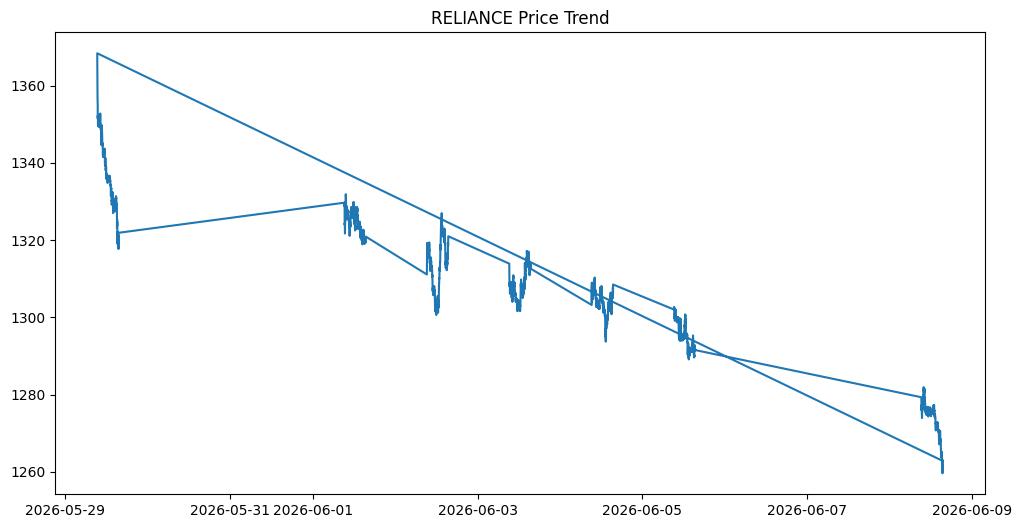

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    reliance["market_timestamp"],
    reliance["close"]
)

plt.title("RELIANCE Price Trend")
plt.show()

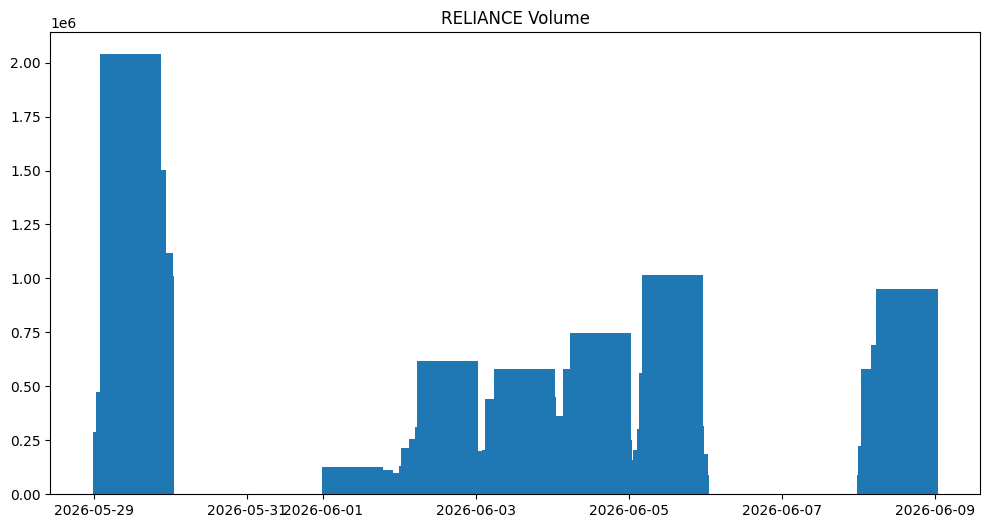

In [10]:
plt.figure(figsize=(12,6))

plt.bar(
    reliance["market_timestamp"],
    reliance["volume"]
)

plt.title("RELIANCE Volume")
plt.show()

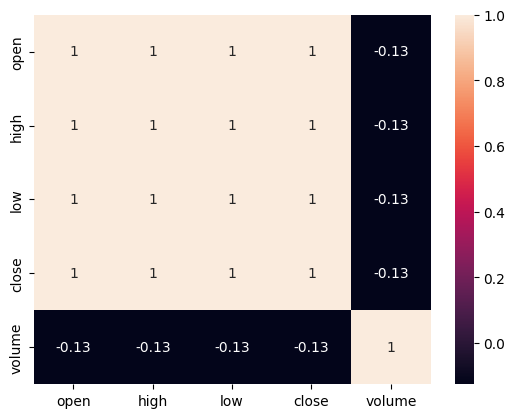

In [11]:
sns.heatmap(
    df[[
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]].corr(),
    annot=True
)

plt.show()

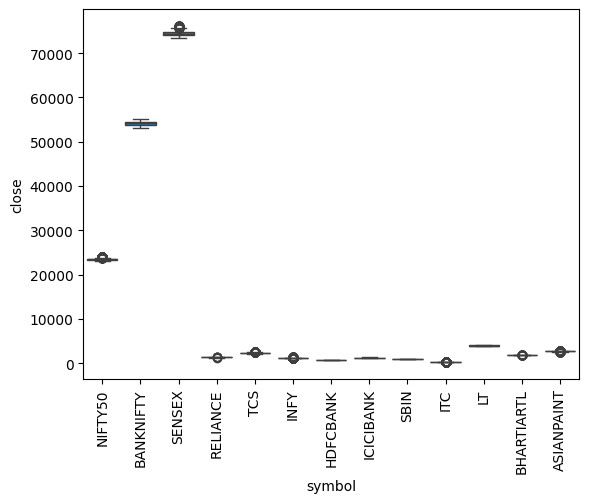

In [12]:
sns.boxplot(
    data=df,
    x="symbol",
    y="close"
)

plt.xticks(rotation=90)
plt.show()

In [13]:
volume_leaders = (
    df.groupby("symbol")["volume"]
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

volume_leaders.head(10)

,symbol,volume
0,HDFCBANK,116543.926095
1,INFY,64271.945524
2,ITC,58714.612952
3,RELIANCE,57037.385524
4,SBIN,48621.288762
5,ICICIBANK,42013.146667
6,BHARTIARTL,34565.476952
7,TCS,24912.670095
8,LT,5466.316190
9,ASIANPAINT,5225.899810


In [14]:
market_summary = pd.DataFrame({
    "Total Records": [len(df)],
    "Unique Symbols": [df["symbol"].nunique()],
    "Average Close": [round(df["close"].mean(), 2)],
    "Average Volume": [round(df["volume"].mean(), 2)]
})

market_summary

,Total Records,Unique Symbols,Average Close,Average Volume
0,34124,13,12955.52,35183.54


In [15]:
reliance = df[
    df["symbol"] == "RELIANCE"
].copy()

reliance.head()

,id,symbol,asset_type,open,high,low,close,volume,ingestion_time,market_timestamp,source,return_pct
3,4,RELIANCE,STOCK,1262.800000,1262.900000,1261.800000,1262.800000,58641,2026-06-08 23:11:07.326910,2026-06-08 15:29:00,Yahoo Finance,0.000000
7884,7914,RELIANCE,STOCK,1364.000000,1368.400024,1361.800049,1368.400024,0,2026-06-08 23:13:36.930512,2026-05-29 09:15:00,Yahoo Finance,0.322582
7885,7915,RELIANCE,STOCK,1368.400024,1368.500000,1362.300049,1364.800049,208266,2026-06-08 23:13:36.930512,2026-05-29 09:16:00,Yahoo Finance,-0.263079
7886,7916,RELIANCE,STOCK,1364.699951,1367.500000,1364.300049,1365.900024,147340,2026-06-08 23:13:36.930512,2026-05-29 09:17:00,Yahoo Finance,0.087937
7887,7917,RELIANCE,STOCK,1366.000000,1366.300049,1361.699951,1362.400024,169931,2026-06-08 23:13:36.930512,2026-05-29 09:18:00,Yahoo Finance,-0.263541


In [16]:
reliance = reliance.sort_values(
    "market_timestamp"
)

reliance["MA20"] = (
    reliance["close"]
    .rolling(20)
    .mean()
)

reliance.tail()

,id,symbol,asset_type,open,high,low,close,volume,ingestion_time,market_timestamp,source,return_pct,MA20
10504,10534,RELIANCE,STOCK,1261.000000,1261.000000,1259.599976,1259.599976,220154,2026-06-08 23:13:36.930512,2026-06-08 15:25:00,Yahoo Finance,-0.111025,1263.375000
10505,10535,RELIANCE,STOCK,1259.900024,1260.000000,1259.199951,1260.000000,105231,2026-06-08 23:13:36.930512,2026-06-08 15:26:00,Yahoo Finance,0.007935,1263.115002
10506,10536,RELIANCE,STOCK,1260.000000,1262.599976,1260.000000,1262.599976,75123,2026-06-08 23:13:36.930512,2026-06-08 15:27:00,Yahoo Finance,0.206347,1263.029999
10507,10537,RELIANCE,STOCK,1262.099976,1263.000000,1262.000000,1262.900024,47725,2026-06-08 23:13:36.930512,2026-06-08 15:28:00,Yahoo Finance,0.063390,1262.990002
3,4,RELIANCE,STOCK,1262.800000,1262.900000,1261.800000,1262.800000,58641,2026-06-08 23:11:07.326910,2026-06-08 15:29:00,Yahoo Finance,0.000000,1262.890000


In [17]:
volatility = np.std(
    reliance["close"]
)

print(
    f"RELIANCE Volatility: "
    f"{volatility:.2f}"
)

RELIANCE Volatility: 19.74


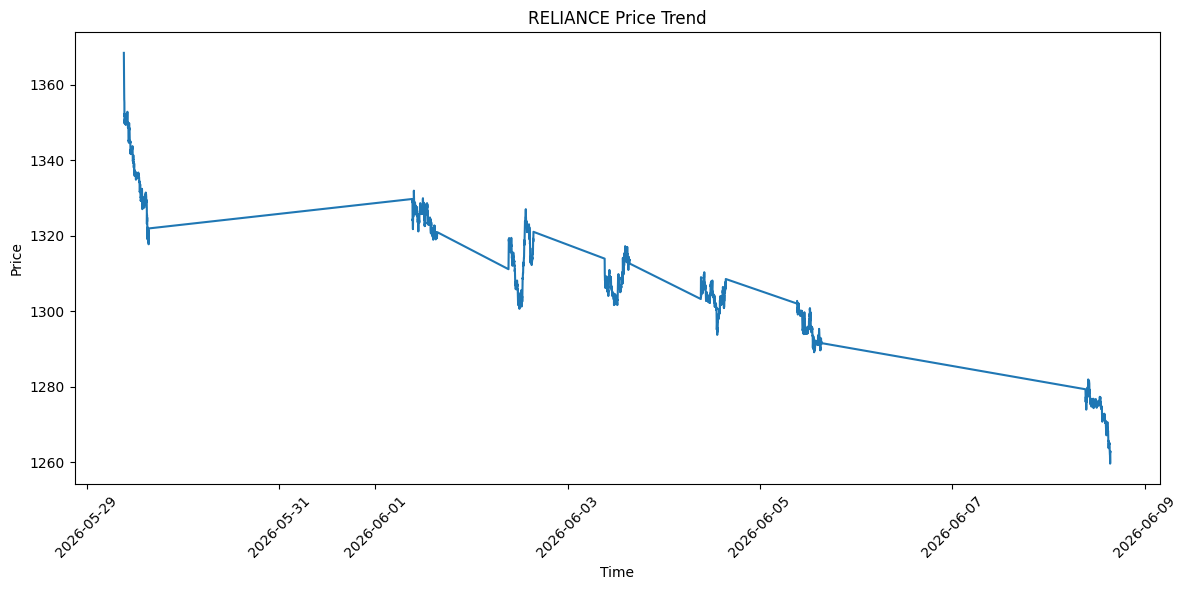

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    reliance["market_timestamp"],
    reliance["close"]
)

plt.title("RELIANCE Price Trend")
plt.xlabel("Time")
plt.ylabel("Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

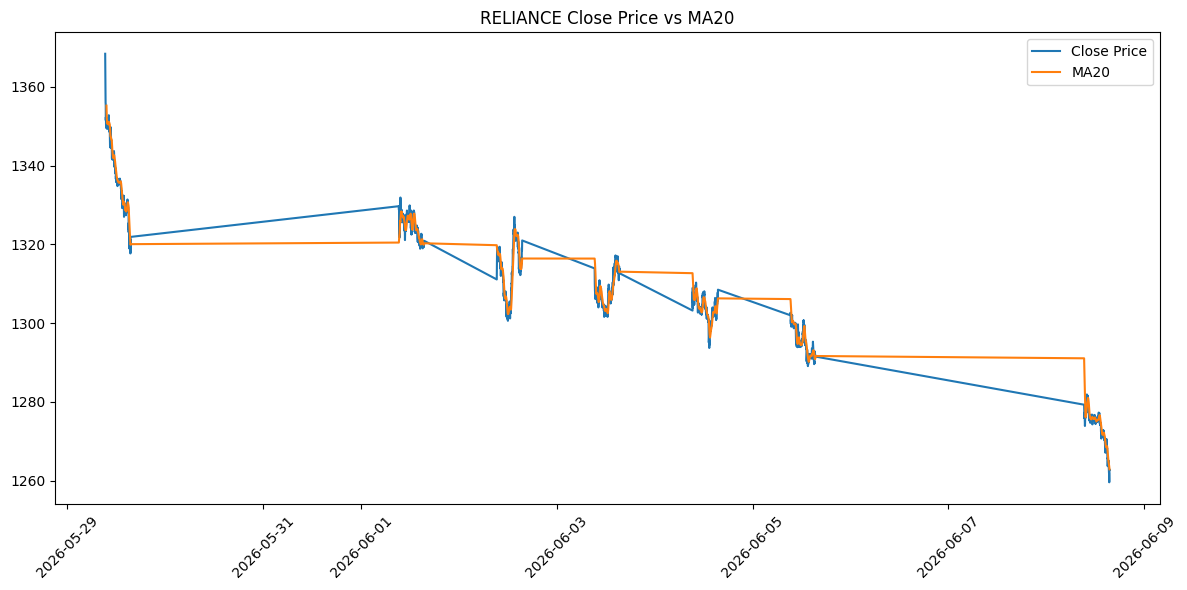

In [19]:
plt.figure(figsize=(12,6))

plt.plot(
    reliance["market_timestamp"],
    reliance["close"],
    label="Close Price"
)

plt.plot(
    reliance["market_timestamp"],
    reliance["MA20"],
    label="MA20"
)

plt.title(
    "RELIANCE Close Price vs MA20"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

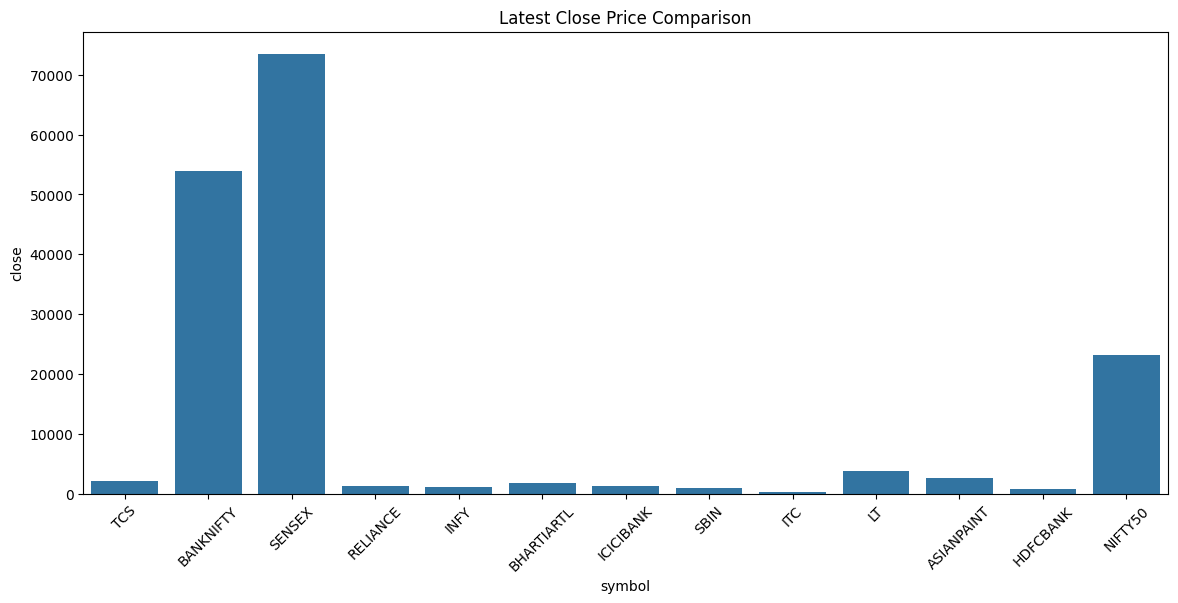

In [20]:
latest_data = (
    df.sort_values("market_timestamp")
      .groupby("symbol")
      .tail(1)
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=latest_data,
    x="symbol",
    y="close"
)

plt.xticks(rotation=45)

plt.title(
    "Latest Close Price Comparison"
)

plt.show()

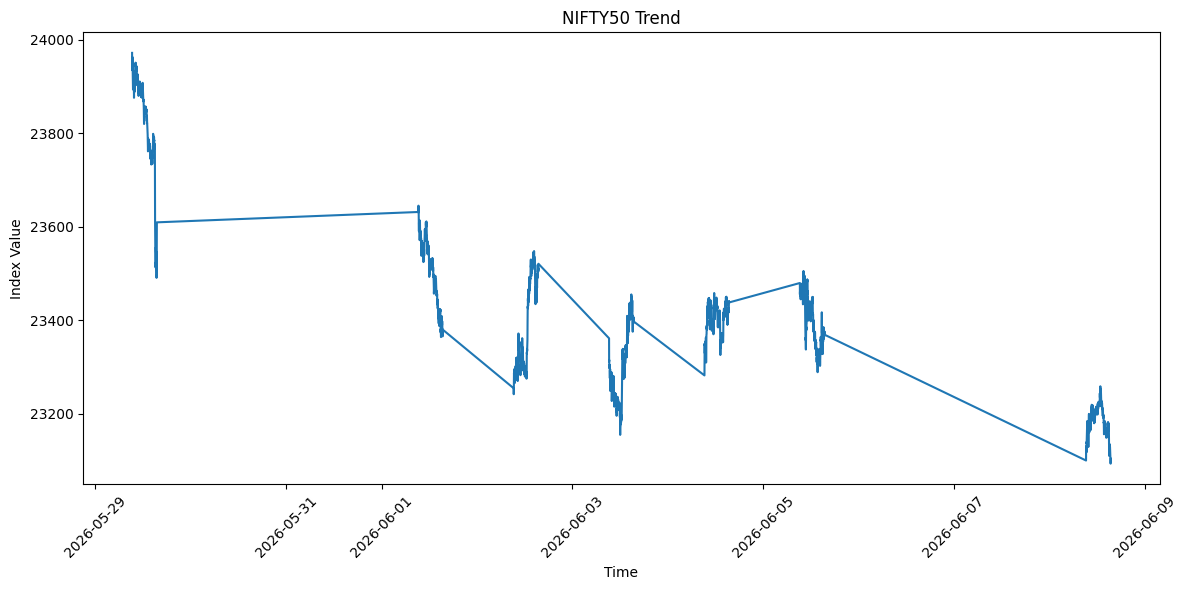

In [21]:
nifty = df[
    df["symbol"] == "NIFTY50"
].copy()

nifty = nifty.sort_values(
    "market_timestamp"
)

plt.figure(figsize=(12,6))

plt.plot(
    nifty["market_timestamp"],
    nifty["close"]
)

plt.title("NIFTY50 Trend")
plt.xlabel("Time")
plt.ylabel("Index Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

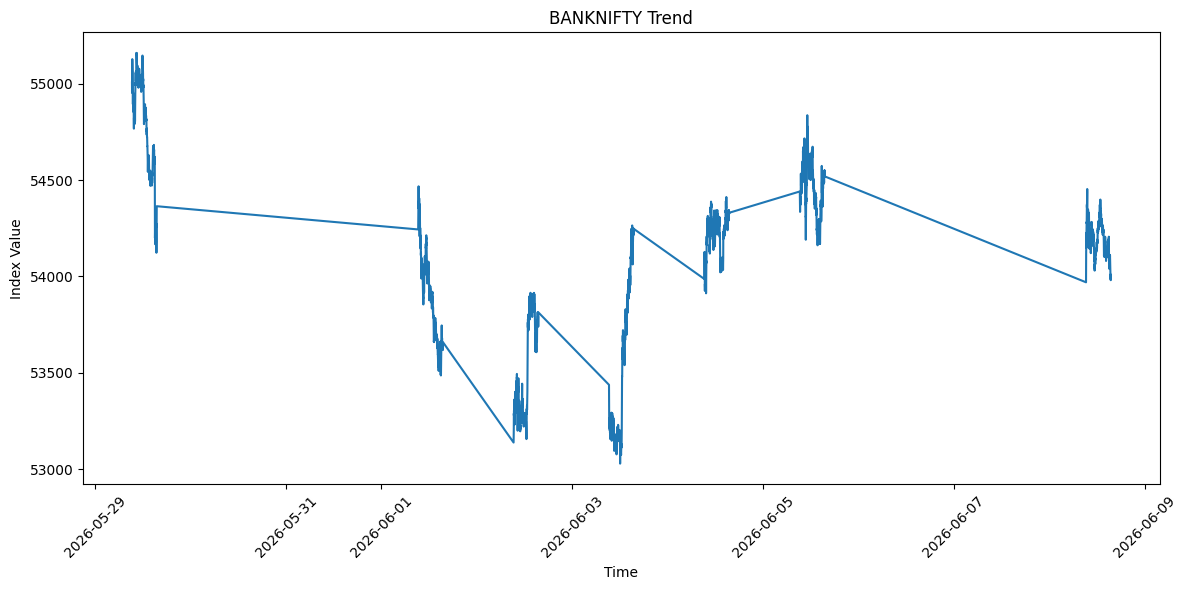

In [22]:
banknifty = df[
    df["symbol"] == "BANKNIFTY"
].copy()

banknifty = banknifty.sort_values(
    "market_timestamp"
)

plt.figure(figsize=(12,6))

plt.plot(
    banknifty["market_timestamp"],
    banknifty["close"]
)

plt.title("BANKNIFTY Trend")
plt.xlabel("Time")
plt.ylabel("Index Value")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

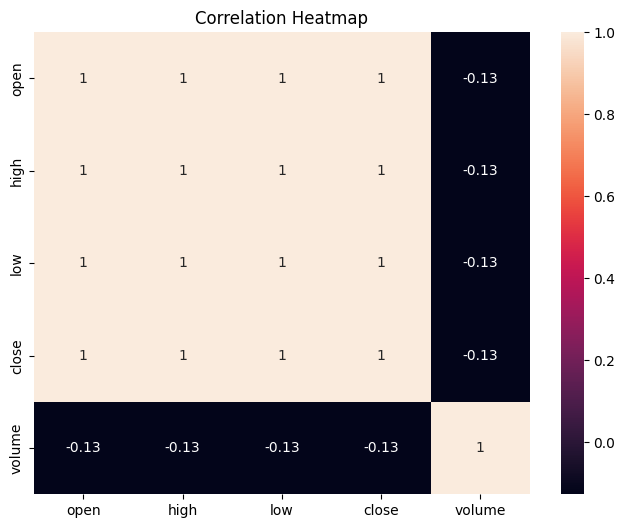

In [23]:
numeric_df = df[
    ["open", "high", "low", "close", "volume"]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [24]:
positive = len(
    df[df["return_pct"] > 0]
)

negative = len(
    df[df["return_pct"] < 0]
)

print(
    f"Positive Stocks: {positive}"
)

print(
    f"Negative Stocks: {negative}"
)

Positive Stocks: 15457
Negative Stocks: 16713
